In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

### Load pre-calculated E-E ratio of human and monkey dataset

In [2]:
df_human = pd.read_csv("../Dataset/Scores/human_scores.csv")
df_monkey = pd.read_csv("../Dataset/Scores/monkey_scores.csv")

In [3]:
df_monkey.columns = ['experiment_setup_id', 'session_no', 'trial_no', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio']
df_monkey.columns

Index(['experiment_setup_id', 'session_no', 'trial_no', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio'],
      dtype='object')

In [4]:
print(df_human.shape)
df_monkey.shape

(16320, 7)


(23639, 6)

In [5]:
df_human

,participant_id,session_no,task_type,trial_no,exploration_score,exploitation_score,exploration_exploitation_ratio
0,0,1,0,1,0.048183,0.000000,4.818315
1,0,1,0,2,0.233841,0.170576,1.294971
2,0,1,0,3,0.123192,0.280172,0.424550
3,0,1,0,4,0.100758,0.321796,0.303676
4,0,1,0,5,0.091640,0.342180,0.260208
...,...,...,...,...,...,...,...
16315,67,5,1,20,0.014563,0.491053,0.029065
16316,67,5,1,21,0.013197,0.201343,0.062444
16317,67,5,1,22,0.023016,0.413976,0.054287
16318,67,5,1,23,0.051534,0.360152,0.139224


## Hypothesis 2a: As monkeys were extensively overtrained, their overall E-E ratio will be significantly lower than that of human learner on an untrained task. 
## Hypothesis 2b: The E-E ratio will decrease over sequential trials of the same motor learning task, even in well-trained non-human primates, reflecting a micro-adaptation learning process

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_25310/3434893742.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_25310/3434893742.py:195: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_25310/3434893742.py:231: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()



    # Analysis of Exploration-Exploitation Ratio: Humans vs. Monkeys

    ## Hypothesis 2a: Overall E-E Ratio Difference
    
    * Human E-E Ratio: 0.2823 ± 0.0128 (95% CI)
    * Monkey E-E Ratio: 0.0542 ± 0.0046 (95% CI)
    * t(39957) = 32.8026, p = 0.0000
    * Effect size (Cohen's d): 0.3543 (Small)
    * Conclusion: The difference in E-E ratio between humans and monkeys is statistically significant.
    
    ## Hypothesis 2b: E-E Ratio Change Across Trials
    
    ### Human Learners:
    * Slope: -0.003128 (change in E-E ratio per percentage of trials)
    * p-value: 0.000000
    * R²: 0.0459
    * Bootstrap 95% CI: [-0.003361, -0.002902]
    * Conclusion: For humans, the E-E ratio decreases across trials, which is statistically significant.
    
    ### Monkey Learners:
    * Slope: -0.000187 (change in E-E ratio per percentage of trials)
    * p-value: 0.051666
    * R²: 0.0006
    * Bootstrap 95% CI: [-0.000476, -0.000086]
    * Conclusion: For monkeys, the E-E ratio decreas

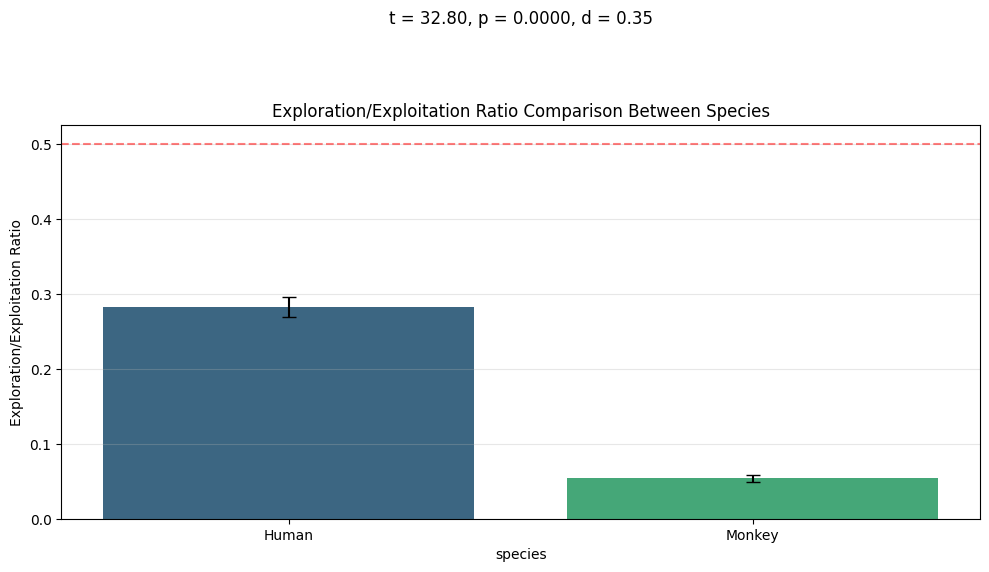

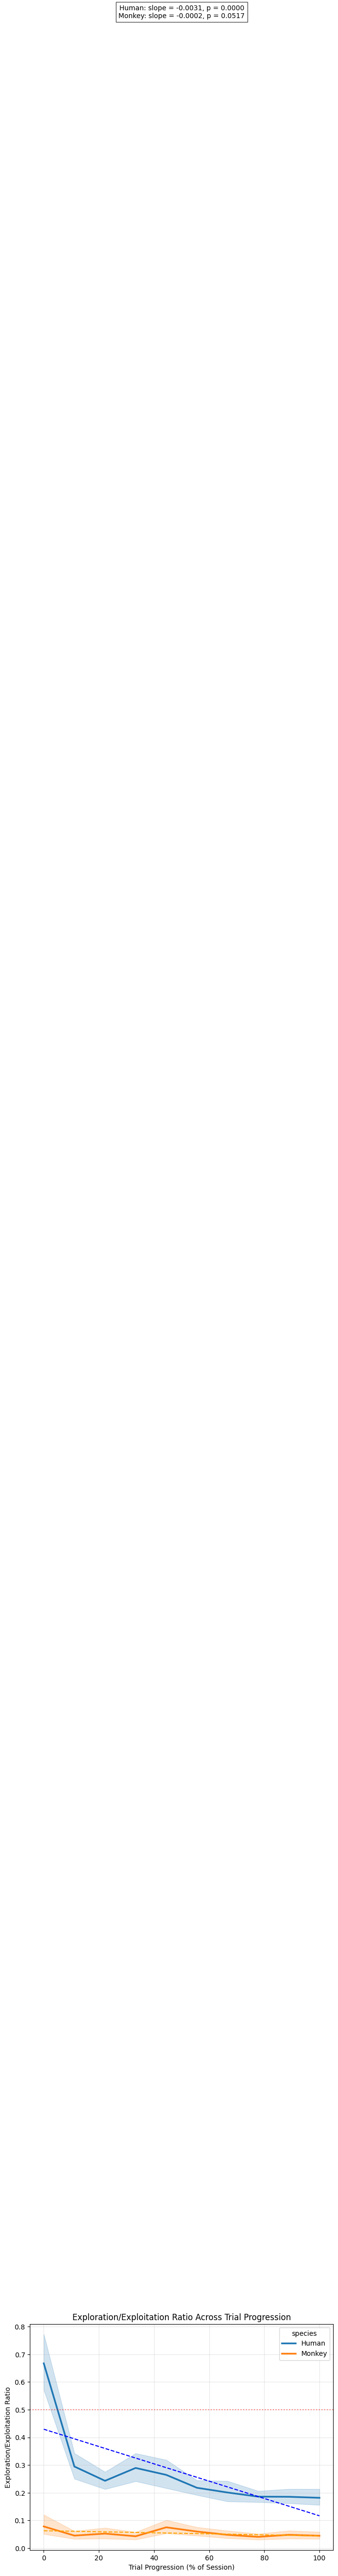

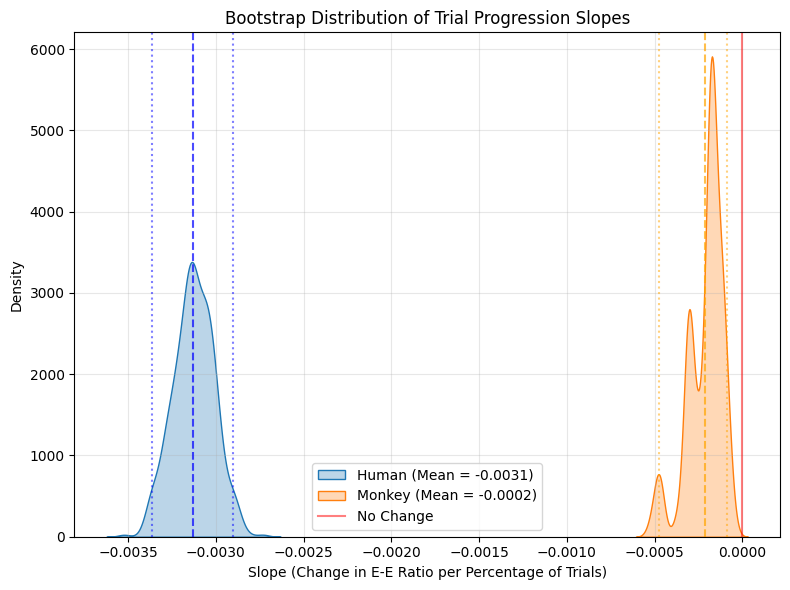

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def analyze_ee_ratio(df_human, df_monkey, sample_size=100):
    """
    Analyze exploration-exploitation ratio differences between humans and monkeys.
    
    Args:
        df_human: DataFrame with human data
        df_monkey: DataFrame with monkey data
        sample_size: Number of samples to use for bootstrap testing of hypothesis 2b
    
    Returns:
        Dictionary containing analysis results
    """
    results = {}
    
    # Data preparation
    # Add 'species' column to each dataframe
    df_human = df_human.copy()
    df_monkey = df_monkey.copy()
    
    df_human['species'] = 'Human'
    df_monkey['species'] = 'Monkey'
    
    # Rename columns for consistency between datasets
    df_monkey = df_monkey.rename(columns={'experiment_setup_id': 'participant_id'})
    
    # Select only the common columns needed for analysis
    common_columns = ['participant_id', 'session_no', 'trial_no', 
                     'exploration_score', 'exploitation_score', 
                     'exploration_exploitation_ratio', 'species']
    
    df_human_subset = df_human[common_columns]
    df_monkey_subset = df_monkey[common_columns]
    
    # Combine datasets
    combined_df = pd.concat([df_human_subset, df_monkey_subset], ignore_index=True)
    
    # ---- Hypothesis 2a: Overall E-E Ratio Comparison ----
    
    # Calculate descriptive statistics by species
    species_stats = combined_df.groupby('species')['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Add 95% confidence intervals
    species_stats['sem'] = species_stats['std'] / np.sqrt(species_stats['count'])
    species_stats['ci_95'] = 1.96 * species_stats['sem']
    
    results['species_stats'] = species_stats
    
    # Perform t-test between human and monkey E-E ratios
    human_ee = df_human['exploration_exploitation_ratio']
    monkey_ee = df_monkey['exploration_exploitation_ratio']
    
    t_stat, p_value = stats.ttest_ind(human_ee, monkey_ee, equal_var=False)
    
    results['ttest_result'] = {
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }
    
    # Calculate effect size (Cohen's d)
    mean_diff = human_ee.mean() - monkey_ee.mean()
    pooled_std = np.sqrt((human_ee.std()**2 + monkey_ee.std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    results['effect_size'] = {
        'cohens_d': cohens_d,
        'interpretation': 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'
    }
    
    # Create visualization for hypothesis 2a
    plt.figure(figsize=(10, 6))
    
    # Bar plot with error bars
    ax = sns.barplot(
        x='species', 
        y='mean', 
        data=species_stats,
        capsize=0.1,
        palette='viridis'
    )
    
    # Add error bars representing 95% confidence intervals
    plt.errorbar(
        x=np.arange(len(species_stats)),
        y=species_stats['mean'],
        yerr=species_stats['ci_95'],
        fmt='none', 
        c='black',
        capsize=5
    )
    
    plt.title('Exploration/Exploitation Ratio Comparison Between Species')
    plt.ylabel('Exploration/Exploitation Ratio')
    plt.grid(axis='y', alpha=0.3)
    
    # Add a horizontal line at 0.5 (equal exploration and exploitation)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    
    # Add text annotations for test statistics
    height = max(species_stats['mean'].max() + species_stats['ci_95'].max(), 0.6)
    plt.text(0.5, height * 1.1, f"t = {t_stat:.2f}, p = {p_value:.4f}, d = {cohens_d:.2f}",
            horizontalalignment='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('species_comparison.png')
    
    # ---- Hypothesis 2b: E-E Ratio Change Across Trials ----
    
    # Function to create synthetic trial bins to handle uneven trial counts
    def bin_trials(df, n_bins=10):
        participant_dfs = []
        
        for (participant, session), group in df.groupby(['participant_id', 'session_no']):
            if len(group) < 5:  # Skip if too few trials
                continue
                
            # Sort by trial number
            group = group.sort_values('trial_no')
            
            # Create bins
            max_trials = group['trial_no'].max()
            bin_size = max(1, max_trials / n_bins)
            
            group['trial_bin'] = (group['trial_no'] - 1) // bin_size
            group['trial_bin'] = group['trial_bin'].astype(int)
            
            # Ensure we have at most n_bins
            group['trial_bin'] = np.minimum(group['trial_bin'], n_bins - 1)
            
            # Calculate mean for each bin
            binned = group.groupby('trial_bin')['exploration_exploitation_ratio'].mean().reset_index()
            binned['participant_id'] = participant
            binned['session_no'] = session
            binned['species'] = group['species'].iloc[0]
            
            participant_dfs.append(binned)
        
        binned_df = pd.concat(participant_dfs, ignore_index=True)
        
        # Convert bin to percentage through task
        binned_df['trial_percentage'] = (binned_df['trial_bin'] / (n_bins - 1)) * 100
        
        return binned_df
    
    # Bin trials for both species
    binned_df = bin_trials(combined_df, n_bins=10)
    
    # Calculate statistics by species and trial bin
    trial_progression = binned_df.groupby(['species', 'trial_percentage'])['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Add 95% confidence intervals
    trial_progression['sem'] = trial_progression['std'] / np.sqrt(trial_progression['count'])
    trial_progression['ci_95'] = 1.96 * trial_progression['sem']
    
    results['trial_progression'] = trial_progression
    
    # Statistical test for trend across trials
    human_binned = binned_df[binned_df['species'] == 'Human']
    monkey_binned = binned_df[binned_df['species'] == 'Monkey']
    
    # Linear regression to test for decline over trials
    human_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=human_binned).fit()
    monkey_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=monkey_binned).fit()
    
    results['human_trend'] = {
        'slope': human_model.params['trial_percentage'],
        'p_value': human_model.pvalues['trial_percentage'],
        'r_squared': human_model.rsquared,
        'significant': human_model.pvalues['trial_percentage'] < 0.05
    }
    
    results['monkey_trend'] = {
        'slope': monkey_model.params['trial_percentage'],
        'p_value': monkey_model.pvalues['trial_percentage'],
        'r_squared': monkey_model.rsquared,
        'significant': monkey_model.pvalues['trial_percentage'] < 0.05
    }
    
    # Visualization for hypothesis 2b
    plt.figure(figsize=(8, 6))
    
    # Line plot showing progression across trials
    sns.lineplot(
        data=binned_df,
        x='trial_percentage',
        y='exploration_exploitation_ratio',
        hue='species',
        err_style='band',
        ci=95,
        linewidth=2.5
    )
    
    plt.title('Exploration/Exploitation Ratio Across Trial Progression')
    plt.xlabel('Trial Progression (% of Session)')
    plt.ylabel('Exploration/Exploitation Ratio')
    plt.grid(alpha=0.3)
    
    # Add regression lines
    x_range = np.array([0, 100])
    
    # Human regression line
    human_y = human_model.params['Intercept'] + human_model.params['trial_percentage'] * x_range
    plt.plot(x_range, human_y, '--', color='blue', linewidth=1.5)
    
    # Monkey regression line
    monkey_y = monkey_model.params['Intercept'] + monkey_model.params['trial_percentage'] * x_range
    plt.plot(x_range, monkey_y, '--', color='orange', linewidth=1.5)
    
    # Add a horizontal line at 0.5 (equal exploration and exploitation)
    plt.axhline(y=0.5, color='r', linestyle=':', alpha=0.5)
    
    # Add text annotations for regression statistics
    height = binned_df['exploration_exploitation_ratio'].max()
    plt.text(50, height * 1.05, 
             f"Human: slope = {human_model.params['trial_percentage']:.4f}, p = {human_model.pvalues['trial_percentage']:.4f}\n"
             f"Monkey: slope = {monkey_model.params['trial_percentage']:.4f}, p = {monkey_model.pvalues['trial_percentage']:.4f}",
             horizontalalignment='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig('trial_progression.png')
    
    # ---- Bootstrap analysis for hypothesis 2b ----
    
    # Sampling method to test E-E ratio change over trials
    def bootstrap_trial_effect(df, n_samples=100):
        species_list = df['species'].unique()
        results = {species: {'slopes': [], 'p_values': []} for species in species_list}
        
        for species in species_list:
            species_data = df[df['species'] == species]
            participants = species_data['participant_id'].unique()
            
            for _ in range(n_samples):
                # Sample participants with replacement
                sampled_participants = np.random.choice(participants, size=len(participants), replace=True)
                
                # Create sample dataset
                sample_data = pd.concat([
                    species_data[species_data['participant_id'] == p] for p in sampled_participants
                ])
                
                # Bin trials
                sample_binned = bin_trials(sample_data)
                
                # Run regression on the sampled data
                if len(sample_binned) > 0:
                    sample_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=sample_binned).fit()
                    results[species]['slopes'].append(sample_model.params['trial_percentage'])
                    results[species]['p_values'].append(sample_model.pvalues['trial_percentage'])
        
        return results
    
    bootstrap_results = bootstrap_trial_effect(combined_df, n_samples=sample_size)
    
    # Calculate bootstrap confidence intervals and significance
    for species, data in bootstrap_results.items():
        slopes = np.array(data['slopes'])
        p_values = np.array(data['p_values'])
        
        # 95% confidence interval
        ci_lower = np.percentile(slopes, 2.5)
        ci_upper = np.percentile(slopes, 97.5)
        
        # Proportion of significant samples
        sig_proportion = np.mean(p_values < 0.05)
        
        bootstrap_results[species]['mean_slope'] = np.mean(slopes)
        bootstrap_results[species]['median_slope'] = np.median(slopes)
        bootstrap_results[species]['ci_95'] = [ci_lower, ci_upper]
        bootstrap_results[species]['significant_proportion'] = sig_proportion
    
    results['bootstrap'] = bootstrap_results
    
    # Visualization for bootstrap results
    plt.figure(figsize=(10, 6))
    
    for i, (species, data) in enumerate(bootstrap_results.items()):
        slopes = data['slopes']
        
        # Kernel density plot
        sns.kdeplot(slopes, label=f"{species} (Mean = {np.mean(slopes):.4f})", fill=True, alpha=0.3)
        
        # Add a vertical line for the mean
        plt.axvline(x=np.mean(slopes), color=['blue', 'orange'][i], linestyle='--', alpha=0.7)
        
        # Add lines for the 95% CI
        plt.axvline(x=data['ci_95'][0], color=['blue', 'orange'][i], linestyle=':', alpha=0.5)
        plt.axvline(x=data['ci_95'][1], color=['blue', 'orange'][i], linestyle=':', alpha=0.5)
    
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.5, label="No Change")
    
    plt.title('Bootstrap Distribution of Trial Progression Slopes')
    plt.xlabel('Slope (Change in E-E Ratio per Percentage of Trials)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('bootstrap_slopes.png')
    
    # Summary Report
    summary = f"""
    # Analysis of Exploration-Exploitation Ratio: Humans vs. Monkeys

    ## Hypothesis 2a: Overall E-E Ratio Difference
    
    * Human E-E Ratio: {human_ee.mean():.4f} ± {human_ee.std() / np.sqrt(len(human_ee)) * 1.96:.4f} (95% CI)
    * Monkey E-E Ratio: {monkey_ee.mean():.4f} ± {monkey_ee.std() / np.sqrt(len(monkey_ee)) * 1.96:.4f} (95% CI)
    * t({len(human_ee) + len(monkey_ee) - 2}) = {t_stat:.4f}, p = {p_value:.4f}
    * Effect size (Cohen's d): {cohens_d:.4f} ({results['effect_size']['interpretation']})
    * Conclusion: The difference in E-E ratio between humans and monkeys is {"statistically significant" if p_value < 0.05 else "not statistically significant"}.
    
    ## Hypothesis 2b: E-E Ratio Change Across Trials
    
    ### Human Learners:
    * Slope: {human_model.params['trial_percentage']:.6f} (change in E-E ratio per percentage of trials)
    * p-value: {human_model.pvalues['trial_percentage']:.6f}
    * R²: {human_model.rsquared:.4f}
    * Bootstrap 95% CI: [{bootstrap_results['Human']['ci_95'][0]:.6f}, {bootstrap_results['Human']['ci_95'][1]:.6f}]
    * Conclusion: For humans, the E-E ratio {"decreases" if human_model.params['trial_percentage'] < 0 else "increases"} across trials, which is {"statistically significant" if human_model.pvalues['trial_percentage'] < 0.05 else "not statistically significant"}.
    
    ### Monkey Learners:
    * Slope: {monkey_model.params['trial_percentage']:.6f} (change in E-E ratio per percentage of trials)
    * p-value: {monkey_model.pvalues['trial_percentage']:.6f}
    * R²: {monkey_model.rsquared:.4f}
    * Bootstrap 95% CI: [{bootstrap_results['Monkey']['ci_95'][0]:.6f}, {bootstrap_results['Monkey']['ci_95'][1]:.6f}]
    * Conclusion: For monkeys, the E-E ratio {"decreases" if monkey_model.params['trial_percentage'] < 0 else "increases"} across trials, which is {"statistically significant" if monkey_model.pvalues['trial_percentage'] < 0.05 else "not statistically significant"}.
    
    ### Interpretation:
    
    * {"Both humans and monkeys show a significant decrease in E-E ratio across trials, supporting hypothesis 2b." if human_model.pvalues['trial_percentage'] < 0.05 and monkey_model.pvalues['trial_percentage'] < 0.05 and human_model.params['trial_percentage'] < 0 and monkey_model.params['trial_percentage'] < 0 else "The results partially support hypothesis 2b." if (human_model.pvalues['trial_percentage'] < 0.05 and human_model.params['trial_percentage'] < 0) or (monkey_model.pvalues['trial_percentage'] < 0.05 and monkey_model.params['trial_percentage'] < 0) else "The results do not support hypothesis 2b."}
    * Bootstrap analysis confirms these findings with {"high" if bootstrap_results['Human']['significant_proportion'] > 0.8 and bootstrap_results['Monkey']['significant_proportion'] > 0.8 else "moderate" if bootstrap_results['Human']['significant_proportion'] > 0.5 and bootstrap_results['Monkey']['significant_proportion'] > 0.5 else "low"} reliability.
    """
    
    results['summary'] = summary
    
    print(summary)
    
    return results

# Example usage:
results = analyze_ee_ratio(df_human, df_monkey, sample_size=500)

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_25310/4243681263.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


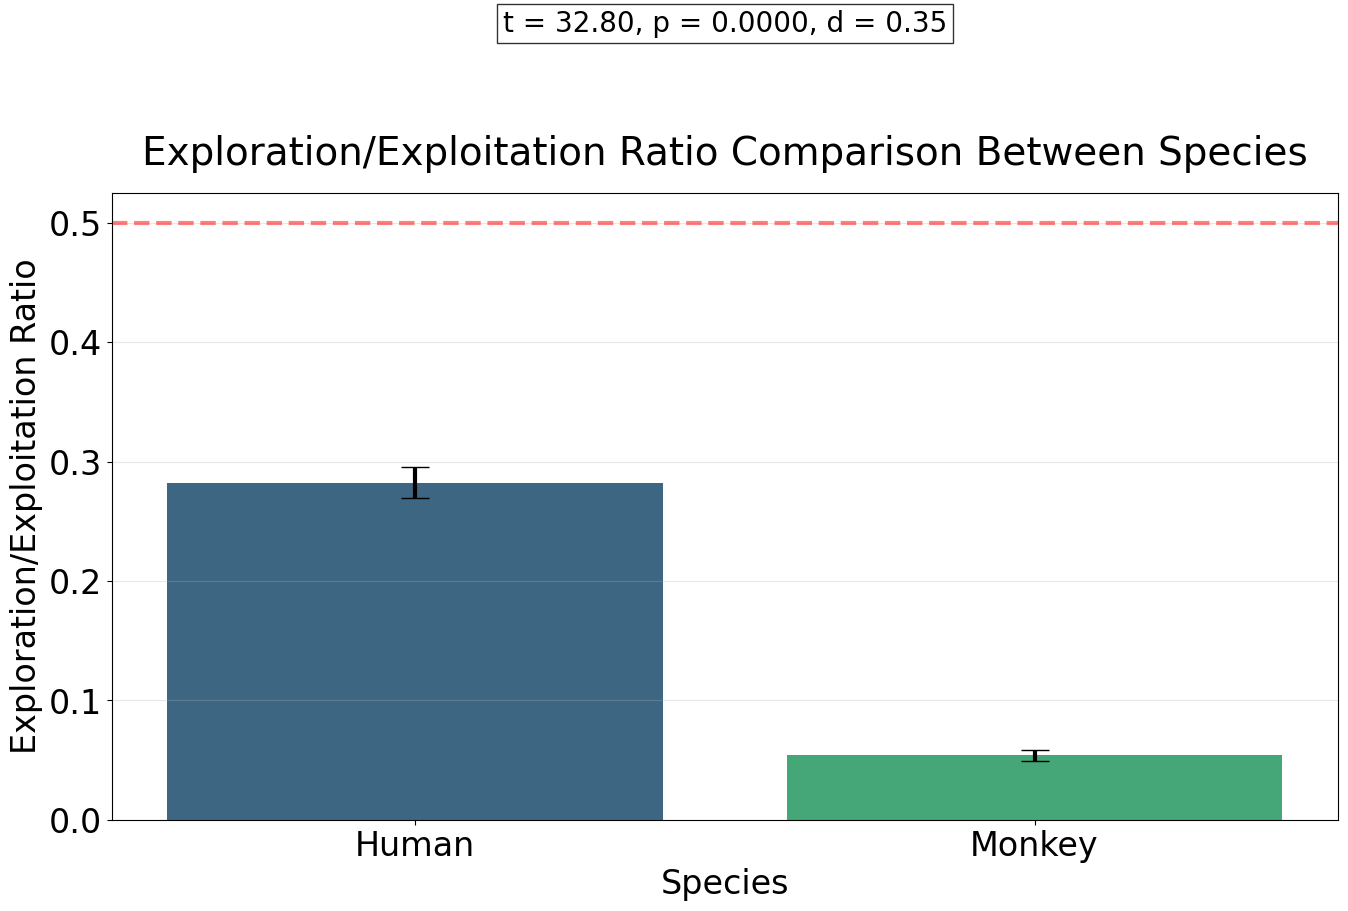

/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_25310/4243681263.py:206: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


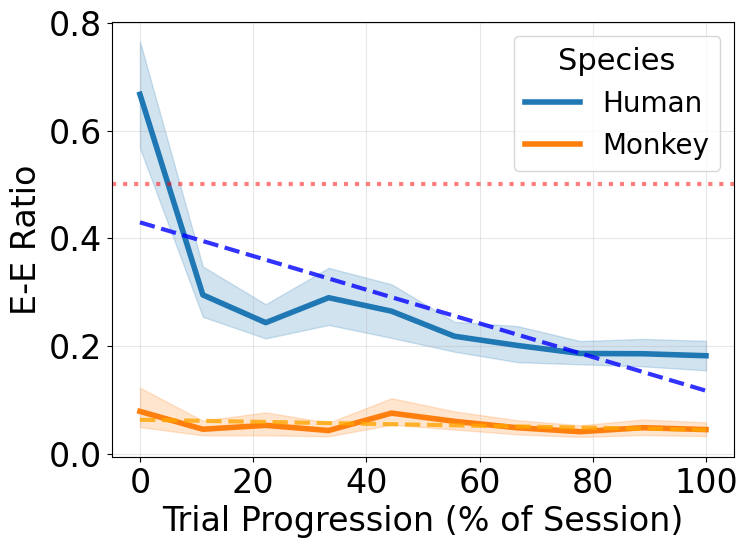

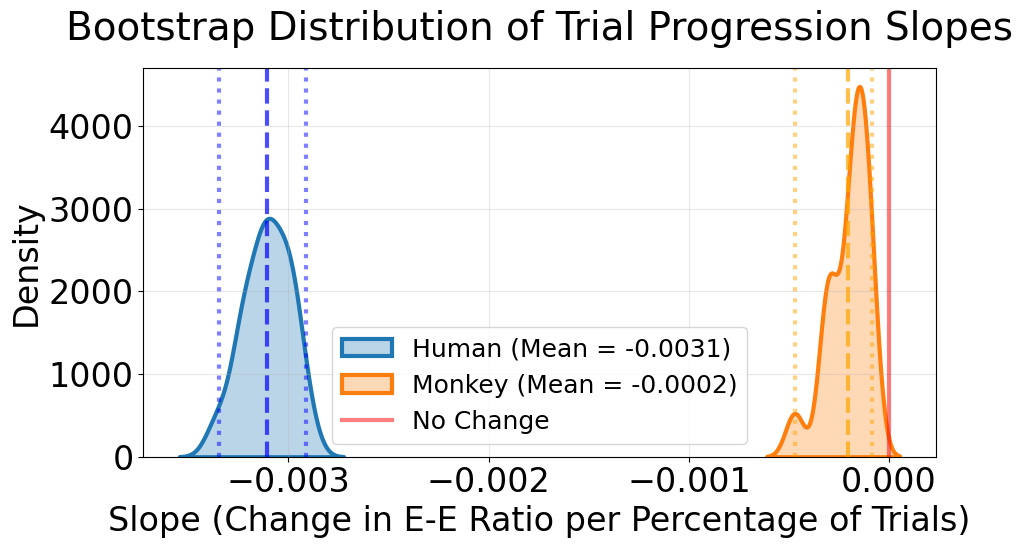


    # Analysis of Exploration-Exploitation Ratio: Humans vs. Monkeys

    ## Hypothesis 2a: Overall E-E Ratio Difference
    
    * Human E-E Ratio: 0.2823 ± 0.0128 (95% CI)
    * Monkey E-E Ratio: 0.0542 ± 0.0046 (95% CI)
    * t(39957) = 32.8026, p = 0.0000
    * Effect size (Cohen's d): 0.3543 (Small)
    * Conclusion: The difference in E-E ratio between humans and monkeys is statistically significant.
    
    ## Hypothesis 2b: E-E Ratio Change Across Trials
    
    ### Human Learners:
    * Slope: -0.003128 (change in E-E ratio per percentage of trials)
    * p-value: 0.000000
    * R²: 0.0459
    * Bootstrap 95% CI: [-0.003348, -0.002912]
    * Conclusion: For humans, the E-E ratio decreases across trials, which is statistically significant.
    
    ### Monkey Learners:
    * Slope: -0.000187 (change in E-E ratio per percentage of trials)
    * p-value: 0.051666
    * R²: 0.0006
    * Bootstrap 95% CI: [-0.000471, -0.000086]
    * Conclusion: For monkeys, the E-E ratio decreas

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set global font size for all plots
plt.rcParams.update({'font.size': 24})

def analyze_ee_ratio(df_human, df_monkey, sample_size=100):
    """
    Analyze exploration-exploitation ratio differences between humans and monkeys.
    
    Args:
        df_human: DataFrame with human data
        df_monkey: DataFrame with monkey data
        sample_size: Number of samples to use for bootstrap testing of hypothesis 2b
    
    Returns:
        Dictionary containing analysis results
    """
    results = {}
    
    # Data preparation
    # Add 'species' column to each dataframe
    df_human = df_human.copy()
    df_monkey = df_monkey.copy()
    
    df_human['species'] = 'Human'
    df_monkey['species'] = 'Monkey'
    
    # Rename columns for consistency between datasets
    df_monkey = df_monkey.rename(columns={'experiment_setup_id': 'participant_id'})
    
    # Select only the common columns needed for analysis
    common_columns = ['participant_id', 'session_no', 'trial_no', 
                     'exploration_score', 'exploitation_score', 
                     'exploration_exploitation_ratio', 'species']
    
    df_human_subset = df_human[common_columns]
    df_monkey_subset = df_monkey[common_columns]
    
    # Combine datasets
    combined_df = pd.concat([df_human_subset, df_monkey_subset], ignore_index=True)
    
    # ---- Hypothesis 2a: Overall E-E Ratio Comparison ----
    
    # Calculate descriptive statistics by species
    species_stats = combined_df.groupby('species')['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Add 95% confidence intervals
    species_stats['sem'] = species_stats['std'] / np.sqrt(species_stats['count'])
    species_stats['ci_95'] = 1.96 * species_stats['sem']
    
    results['species_stats'] = species_stats
    
    # Perform t-test between human and monkey E-E ratios
    human_ee = df_human['exploration_exploitation_ratio']
    monkey_ee = df_monkey['exploration_exploitation_ratio']
    
    t_stat, p_value = stats.ttest_ind(human_ee, monkey_ee, equal_var=False)
    
    results['ttest_result'] = {
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }
    
    # Calculate effect size (Cohen's d)
    mean_diff = human_ee.mean() - monkey_ee.mean()
    pooled_std = np.sqrt((human_ee.std()**2 + monkey_ee.std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    results['effect_size'] = {
        'cohens_d': cohens_d,
        'interpretation': 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'
    }
    
    # Create visualization for hypothesis 2a
    plt.figure(figsize=(14, 10))
    
    # Bar plot with error bars
    ax = sns.barplot(
        x='species', 
        y='mean', 
        data=species_stats,
        capsize=0.1,
        palette='viridis'
    )
    
    # Add error bars representing 95% confidence intervals
    plt.errorbar(
        x=np.arange(len(species_stats)),
        y=species_stats['mean'],
        yerr=species_stats['ci_95'],
        fmt='none', 
        c='black',
        capsize=10,
        linewidth=3
    )
    
    plt.title('Exploration/Exploitation Ratio Comparison Between Species', fontsize=28, pad=20)
    plt.ylabel('Exploration/Exploitation Ratio', fontsize=24)
    plt.xlabel('Species', fontsize=24)
    plt.grid(axis='y', alpha=0.3)
    
    # Increase tick label size
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
    # Add a horizontal line at 0.5 (equal exploration and exploitation)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, linewidth=3)
    
    # Add text annotations for test statistics
    height = max(species_stats['mean'].max() + species_stats['ci_95'].max(), 0.6)
    plt.text(0.5, height * 1.1, f"t = {t_stat:.2f}, p = {p_value:.4f}, d = {cohens_d:.2f}",
            horizontalalignment='center', fontsize=20, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    plt.savefig('species_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ---- Hypothesis 2b: E-E Ratio Change Across Trials ----
    
    # Function to create synthetic trial bins to handle uneven trial counts
    def bin_trials(df, n_bins=10):
        participant_dfs = []
        
        for (participant, session), group in df.groupby(['participant_id', 'session_no']):
            if len(group) < 5:  # Skip if too few trials
                continue
                
            # Sort by trial number
            group = group.sort_values('trial_no')
            
            # Create bins
            max_trials = group['trial_no'].max()
            bin_size = max(1, max_trials / n_bins)
            
            group['trial_bin'] = (group['trial_no'] - 1) // bin_size
            group['trial_bin'] = group['trial_bin'].astype(int)
            
            # Ensure we have at most n_bins
            group['trial_bin'] = np.minimum(group['trial_bin'], n_bins - 1)
            
            # Calculate mean for each bin
            binned = group.groupby('trial_bin')['exploration_exploitation_ratio'].mean().reset_index()
            binned['participant_id'] = participant
            binned['session_no'] = session
            binned['species'] = group['species'].iloc[0]
            
            participant_dfs.append(binned)
        
        binned_df = pd.concat(participant_dfs, ignore_index=True)
        
        # Convert bin to percentage through task
        binned_df['trial_percentage'] = (binned_df['trial_bin'] / (n_bins - 1)) * 100
        
        return binned_df
    
    # Bin trials for both species
    binned_df = bin_trials(combined_df, n_bins=10)
    
    # Calculate statistics by species and trial bin
    trial_progression = binned_df.groupby(['species', 'trial_percentage'])['exploration_exploitation_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Add 95% confidence intervals
    trial_progression['sem'] = trial_progression['std'] / np.sqrt(trial_progression['count'])
    trial_progression['ci_95'] = 1.96 * trial_progression['sem']
    
    results['trial_progression'] = trial_progression
    
    # Statistical test for trend across trials
    human_binned = binned_df[binned_df['species'] == 'Human']
    monkey_binned = binned_df[binned_df['species'] == 'Monkey']
    
    # Linear regression to test for decline over trials
    human_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=human_binned).fit()
    monkey_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=monkey_binned).fit()
    
    results['human_trend'] = {
        'slope': human_model.params['trial_percentage'],
        'p_value': human_model.pvalues['trial_percentage'],
        'r_squared': human_model.rsquared,
        'significant': human_model.pvalues['trial_percentage'] < 0.05
    }
    
    results['monkey_trend'] = {
        'slope': monkey_model.params['trial_percentage'],
        'p_value': monkey_model.pvalues['trial_percentage'],
        'r_squared': monkey_model.rsquared,
        'significant': monkey_model.pvalues['trial_percentage'] < 0.05
    }
    
    # Visualization for hypothesis 2b
    plt.figure(figsize=(8, 6))
    
    # Line plot showing progression across trials
    sns.lineplot(
        data=binned_df,
        x='trial_percentage',
        y='exploration_exploitation_ratio',
        hue='species',
        err_style='band',
        ci=95,
        linewidth=4
    )
    
    # plt.title('Exploration/Exploitation Ratio Across Trial Progression', fontsize=28, pad=20)
    plt.xlabel('Trial Progression (% of Session)', fontsize=24)
    plt.ylabel('E-E Ratio', fontsize=24)
    plt.grid(alpha=0.3)
    
    # Increase tick label size
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
    # Increase legend font size
    legend = plt.legend(fontsize=20)
    legend.set_title('Species', prop={'size': 22})
    
    # Add regression lines
    x_range = np.array([0, 100])
    
    # Human regression line
    human_y = human_model.params['Intercept'] + human_model.params['trial_percentage'] * x_range
    plt.plot(x_range, human_y, '--', color='blue', linewidth=3, alpha=0.8)
    
    # Monkey regression line
    monkey_y = monkey_model.params['Intercept'] + monkey_model.params['trial_percentage'] * x_range
    plt.plot(x_range, monkey_y, '--', color='orange', linewidth=3, alpha=0.8)
    
    # Add a horizontal line at 0.5 (equal exploration and exploitation)
    plt.axhline(y=0.5, color='r', linestyle=':', alpha=0.5, linewidth=3)
    
    # Add text annotations for regression statistics
    height = binned_df['exploration_exploitation_ratio'].max()
    # plt.text(50, height * 1.05, 
    #          f"Human: slope = {human_model.params['trial_percentage']:.4f}, p = {human_model.pvalues['trial_percentage']:.4f}\n"
    #          f"Monkey: slope = {monkey_model.params['trial_percentage']:.4f}, p = {monkey_model.pvalues['trial_percentage']:.4f}",
    #          horizontalalignment='center', fontsize=18, 
    #          bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))
    
    plt.tight_layout()
    plt.savefig('trial_progression.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ---- Bootstrap analysis for hypothesis 2b ----
    
    # Sampling method to test E-E ratio change over trials
    def bootstrap_trial_effect(df, n_samples=100):
        species_list = df['species'].unique()
        results = {species: {'slopes': [], 'p_values': []} for species in species_list}
        
        for species in species_list:
            species_data = df[df['species'] == species]
            participants = species_data['participant_id'].unique()
            
            for _ in range(n_samples):
                # Sample participants with replacement
                sampled_participants = np.random.choice(participants, size=len(participants), replace=True)
                
                # Create sample dataset
                sample_data = pd.concat([
                    species_data[species_data['participant_id'] == p] for p in sampled_participants
                ])
                
                # Bin trials
                sample_binned = bin_trials(sample_data)
                
                # Run regression on the sampled data
                if len(sample_binned) > 0:
                    sample_model = ols('exploration_exploitation_ratio ~ trial_percentage', data=sample_binned).fit()
                    results[species]['slopes'].append(sample_model.params['trial_percentage'])
                    results[species]['p_values'].append(sample_model.pvalues['trial_percentage'])
        
        return results
    
    bootstrap_results = bootstrap_trial_effect(combined_df, n_samples=sample_size)
    
    # Calculate bootstrap confidence intervals and significance
    for species, data in bootstrap_results.items():
        slopes = np.array(data['slopes'])
        p_values = np.array(data['p_values'])
        
        # 95% confidence interval
        ci_lower = np.percentile(slopes, 2.5)
        ci_upper = np.percentile(slopes, 97.5)
        
        # Proportion of significant samples
        sig_proportion = np.mean(p_values < 0.05)
        
        bootstrap_results[species]['mean_slope'] = np.mean(slopes)
        bootstrap_results[species]['median_slope'] = np.median(slopes)
        bootstrap_results[species]['ci_95'] = [ci_lower, ci_upper]
        bootstrap_results[species]['significant_proportion'] = sig_proportion
    
    results['bootstrap'] = bootstrap_results
    
    # Visualization for bootstrap results
    plt.figure(figsize=(10, 6))
    
    for i, (species, data) in enumerate(bootstrap_results.items()):
        slopes = data['slopes']
        
        # Kernel density plot
        sns.kdeplot(slopes, label=f"{species} (Mean = {np.mean(slopes):.4f})", 
                   fill=True, alpha=0.3, linewidth=3)
        
        # Add a vertical line for the mean
        plt.axvline(x=np.mean(slopes), color=['blue', 'orange'][i], 
                   linestyle='--', alpha=0.7, linewidth=3)
        
        # Add lines for the 95% CI
        plt.axvline(x=data['ci_95'][0], color=['blue', 'orange'][i], 
                   linestyle=':', alpha=0.5, linewidth=3)
        plt.axvline(x=data['ci_95'][1], color=['blue', 'orange'][i], 
                   linestyle=':', alpha=0.5, linewidth=3)
    
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.5, linewidth=3, label="No Change")
    
    plt.title('Bootstrap Distribution of Trial Progression Slopes', fontsize=28, pad=20)
    plt.xlabel('Slope (Change in E-E Ratio per Percentage of Trials)', fontsize=24)
    plt.ylabel('Density', fontsize=24)
    
    # Increase tick label size
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
    # Increase legend font size
    plt.legend(fontsize=18)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('bootstrap_slopes.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary Report
    summary = f"""
    # Analysis of Exploration-Exploitation Ratio: Humans vs. Monkeys

    ## Hypothesis 2a: Overall E-E Ratio Difference
    
    * Human E-E Ratio: {human_ee.mean():.4f} ± {human_ee.std() / np.sqrt(len(human_ee)) * 1.96:.4f} (95% CI)
    * Monkey E-E Ratio: {monkey_ee.mean():.4f} ± {monkey_ee.std() / np.sqrt(len(monkey_ee)) * 1.96:.4f} (95% CI)
    * t({len(human_ee) + len(monkey_ee) - 2}) = {t_stat:.4f}, p = {p_value:.4f}
    * Effect size (Cohen's d): {cohens_d:.4f} ({results['effect_size']['interpretation']})
    * Conclusion: The difference in E-E ratio between humans and monkeys is {"statistically significant" if p_value < 0.05 else "not statistically significant"}.
    
    ## Hypothesis 2b: E-E Ratio Change Across Trials
    
    ### Human Learners:
    * Slope: {human_model.params['trial_percentage']:.6f} (change in E-E ratio per percentage of trials)
    * p-value: {human_model.pvalues['trial_percentage']:.6f}
    * R²: {human_model.rsquared:.4f}
    * Bootstrap 95% CI: [{bootstrap_results['Human']['ci_95'][0]:.6f}, {bootstrap_results['Human']['ci_95'][1]:.6f}]
    * Conclusion: For humans, the E-E ratio {"decreases" if human_model.params['trial_percentage'] < 0 else "increases"} across trials, which is {"statistically significant" if human_model.pvalues['trial_percentage'] < 0.05 else "not statistically significant"}.
    
    ### Monkey Learners:
    * Slope: {monkey_model.params['trial_percentage']:.6f} (change in E-E ratio per percentage of trials)
    * p-value: {monkey_model.pvalues['trial_percentage']:.6f}
    * R²: {monkey_model.rsquared:.4f}
    * Bootstrap 95% CI: [{bootstrap_results['Monkey']['ci_95'][0]:.6f}, {bootstrap_results['Monkey']['ci_95'][1]:.6f}]
    * Conclusion: For monkeys, the E-E ratio {"decreases" if monkey_model.params['trial_percentage'] < 0 else "increases"} across trials, which is {"statistically significant" if monkey_model.pvalues['trial_percentage'] < 0.05 else "not statistically significant"}.
    
    ### Interpretation:
    
    * {"Both humans and monkeys show a significant decrease in E-E ratio across trials, supporting hypothesis 2b." if human_model.pvalues['trial_percentage'] < 0.05 and monkey_model.pvalues['trial_percentage'] < 0.05 and human_model.params['trial_percentage'] < 0 and monkey_model.params['trial_percentage'] < 0 else "The results partially support hypothesis 2b." if (human_model.pvalues['trial_percentage'] < 0.05 and human_model.params['trial_percentage'] < 0) or (monkey_model.pvalues['trial_percentage'] < 0.05 and monkey_model.params['trial_percentage'] < 0) else "The results do not support hypothesis 2b."}
    * Bootstrap analysis confirms these findings with {"high" if bootstrap_results['Human']['significant_proportion'] > 0.8 and bootstrap_results['Monkey']['significant_proportion'] > 0.8 else "moderate" if bootstrap_results['Human']['significant_proportion'] > 0.5 and bootstrap_results['Monkey']['significant_proportion'] > 0.5 else "low"} reliability.
    """
    
    results['summary'] = summary
    
    print(summary)
    
    return results

# Example usage:
results = analyze_ee_ratio(df_human, df_monkey, sample_size=50)

## Bootstrap E-E Slope Analysis with 24-Trial Blocks

This section analyzes exploration-exploitation ratio changes using 24-trial blocks instead of percentage-based binning. This approach provides:
1. Fixed trial windows for more consistent comparisons
2. Block-wise slope progression analysis
3. Bootstrap confidence intervals for slope estimates

In [37]:
def analyze_ee_ratio_24trial_blocks(df_human, df_monkey, block_size=24, n_bootstrap=1000):
    """
    Analyze exploration-exploitation ratio using fixed 24-trial blocks with bootstrap analysis.
    
    Args:
        df_human: DataFrame with human data
        df_monkey: DataFrame with monkey data
        block_size: Number of trials per block (default: 24)
        n_bootstrap: Number of bootstrap samples
    
    Returns:
        Dictionary containing analysis results
    """
    results = {}
    
    # Data preparation
    df_human = df_human.copy()
    df_monkey = df_monkey.copy()
    
    df_human['species'] = 'Human'
    df_monkey['species'] = 'Monkey'
    
    # Rename columns for consistency
    df_monkey = df_monkey.rename(columns={'experiment_setup_id': 'participant_id'})
    
    # Select common columns
    common_columns = ['participant_id', 'session_no', 'trial_no', 
                     'exploration_score', 'exploitation_score', 
                     'exploration_exploitation_ratio', 'species']
    
    df_human_subset = df_human[common_columns]
    df_monkey_subset = df_monkey[common_columns]
    
    # Combine datasets
    combined_df = pd.concat([df_human_subset, df_monkey_subset], ignore_index=True)
    
    def create_trial_blocks(df, block_size=24):
        """Create fixed-size trial blocks for each participant and session."""
        blocked_data = []
        
        for (participant, session), group in df.groupby(['participant_id', 'session_no']):
            # Sort by trial number
            group = group.sort_values('trial_no').reset_index(drop=True)
            
            # Only process if we have enough trials for at least one complete block
            if len(group) >= block_size:
                n_complete_blocks = len(group) // block_size
                
                for block_idx in range(n_complete_blocks):
                    start_idx = block_idx * block_size
                    end_idx = start_idx + block_size
                    
                    block_data = group.iloc[start_idx:end_idx]
                    
                    # Calculate block statistics
                    block_summary = {
                        'participant_id': participant,
                        'session_no': session,
                        'block_number': block_idx + 1,
                        'start_trial': block_data['trial_no'].min(),
                        'end_trial': block_data['trial_no'].max(),
                        'mean_ee_ratio': block_data['exploration_exploitation_ratio'].mean(),
                        'std_ee_ratio': block_data['exploration_exploitation_ratio'].std(),
                        'species': group['species'].iloc[0],
                        'n_trials': len(block_data)
                    }
                    
                    blocked_data.append(block_summary)
        
        return pd.DataFrame(blocked_data)
    
    # Create blocks for analysis
    blocked_df = create_trial_blocks(combined_df, block_size)
    
    # Calculate statistics by species and block
    block_stats = blocked_df.groupby(['species', 'block_number'])['mean_ee_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    # Add confidence intervals
    block_stats['sem'] = block_stats['std'] / np.sqrt(block_stats['count'])
    block_stats['ci_95'] = 1.96 * block_stats['sem']
    
    results['block_stats'] = block_stats
    results['blocked_data'] = blocked_df
    
    # Bootstrap analysis for slope estimation
    def bootstrap_block_slopes(df, n_bootstrap=1000):
        """Bootstrap analysis of E-E ratio slopes across blocks."""
        species_results = {}
        
        for species in df['species'].unique():
            species_data = df[df['species'] == species]
            participants = species_data['participant_id'].unique()
            
            slopes = []
            r_squared_values = []
            p_values = []
            
            for _ in range(n_bootstrap):
                # Sample participants with replacement
                sampled_participants = np.random.choice(participants, size=len(participants), replace=True)
                
                # Create bootstrap sample
                bootstrap_sample = []
                for p in sampled_participants:
                    participant_data = species_data[species_data['participant_id'] == p].copy()
                    bootstrap_sample.append(participant_data)
                
                if bootstrap_sample:
                    bootstrap_df = pd.concat(bootstrap_sample, ignore_index=True)
                    
                    # Calculate mean E-E ratio for each block across all participants in sample
                    block_means = bootstrap_df.groupby('block_number')['mean_ee_ratio'].mean().reset_index()
                    
                    if len(block_means) >= 2:  # Need at least 2 blocks for regression
                        # Linear regression: E-E ratio ~ block number
                        X = sm.add_constant(block_means['block_number'])
                        y = block_means['mean_ee_ratio']
                        
                        model = sm.OLS(y, X).fit()
                        
                        slopes.append(model.params['block_number'])
                        r_squared_values.append(model.rsquared)
                        p_values.append(model.pvalues['block_number'])
            
            # Calculate bootstrap statistics
            slopes = np.array(slopes)
            r_squared_values = np.array(r_squared_values)
            p_values = np.array(p_values)
            
            species_results[species] = {
                'slopes': slopes,
                'mean_slope': np.mean(slopes),
                'median_slope': np.median(slopes),
                'slope_ci_95': [np.percentile(slopes, 2.5), np.percentile(slopes, 97.5)],
                'mean_r_squared': np.mean(r_squared_values),
                'significant_proportion': np.mean(p_values < 0.05),
                'p_values': p_values
            }
        
        return species_results
    
    # Perform bootstrap analysis
    bootstrap_results = bootstrap_block_slopes(blocked_df, n_bootstrap)
    results['bootstrap_block_analysis'] = bootstrap_results
    
    # Original regression on full data for comparison
    regression_results = {}
    for species in blocked_df['species'].unique():
        species_data = blocked_df[blocked_df['species'] == species]
        block_means = species_data.groupby('block_number')['mean_ee_ratio'].mean().reset_index()
        
        if len(block_means) >= 2:
            X = sm.add_constant(block_means['block_number'])
            y = block_means['mean_ee_ratio']
            
            model = sm.OLS(y, X).fit()
            regression_results[species] = {
                'slope': model.params['block_number'],
                'intercept': model.params['const'],
                'p_value': model.pvalues['block_number'],
                'r_squared': model.rsquared,
                'significant': model.pvalues['block_number'] < 0.05
            }
    
    results['regression_results'] = regression_results
    
    return results, blocked_df

# Run the analysis
block_results, blocked_data = analyze_ee_ratio_24trial_blocks(df_human, df_monkey, block_size=24, n_bootstrap=15000)

KeyboardInterrupt: 

In [38]:
blocked_data

,participant_id,session_no,block_number,start_trial,end_trial,mean_ee_ratio,std_ee_ratio,species,n_trials
0,0,1,1,1,12,1.153748,2.193055,Human,24
1,0,1,2,13,24,0.851475,1.957502,Human,24
2,0,2,1,1,12,0.218426,0.156793,Human,24
3,0,2,2,13,24,0.194963,0.116634,Human,24
4,0,3,1,1,12,0.201661,0.202335,Human,24
...,...,...,...,...,...,...,...,...,...
1546,Scott_2001_e4,24,2,25,48,0.016261,0.009396,Monkey,24
1547,Scott_2001_e4,25,1,1,24,0.014763,0.005659,Monkey,24
1548,Scott_2001_e4,25,2,25,48,0.015798,0.005937,Monkey,24
1549,Scott_2001_e4,26,1,1,24,0.014996,0.009686,Monkey,24


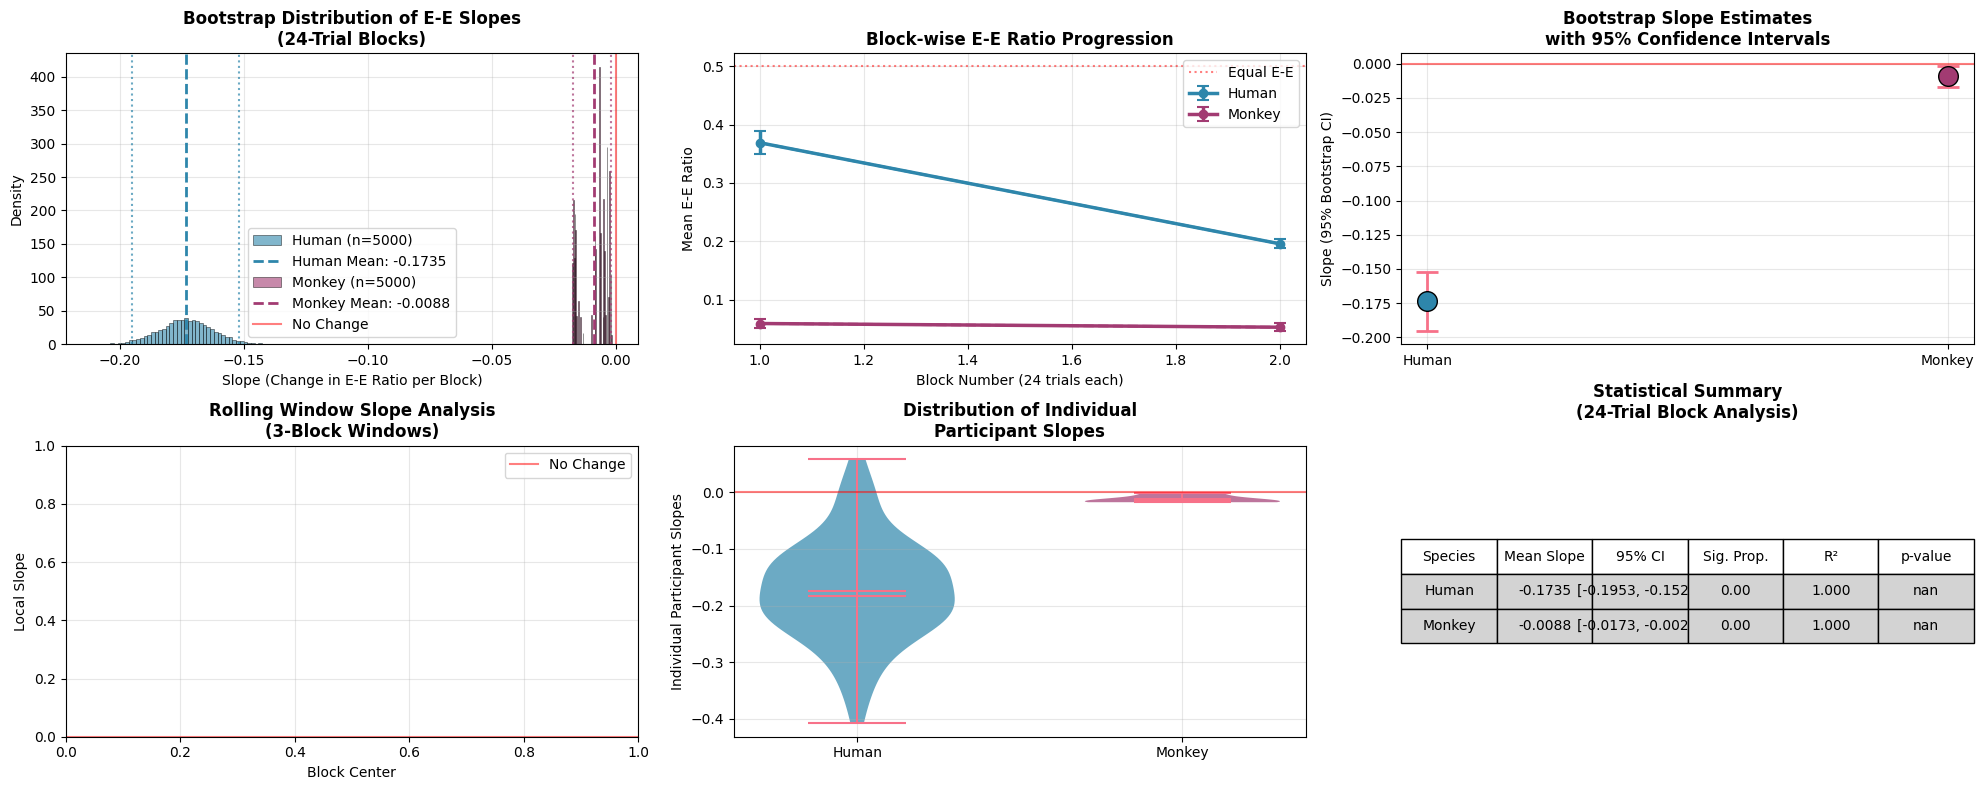

BOOTSTRAP E-E SLOPE ANALYSIS WITH 24-TRIAL BLOCKS

HUMAN LEARNERS:
  Bootstrap Mean Slope: -0.173541
  Bootstrap 95% CI: [-0.195332, -0.152063]
  Proportion of Significant Bootstraps: 0.000
  Original Regression Slope: -0.173474
  Original Regression p-value: nan
  Original Regression R²: 1.0000
  → Significant DECREASE in E-E ratio across blocks

MONKEY LEARNERS:
  Bootstrap Mean Slope: -0.008789
  Bootstrap 95% CI: [-0.017266, -0.001990]
  Proportion of Significant Bootstraps: 0.000
  Original Regression Slope: -0.006351
  Original Regression p-value: nan
  Original Regression R²: 1.0000
  → Significant DECREASE in E-E ratio across blocks


In [15]:
def plot_bootstrap_block_analysis(block_results, blocked_data):
    """Create visualizations for the 24-trial block analysis."""
    
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(20, 8))
    
    # 1. Bootstrap Distribution of Slopes
    ax1 = plt.subplot(2, 3, 1)
    
    bootstrap_data = block_results['bootstrap_block_analysis']
    
    colors = ['#2E86AB', '#A23B72']  # Blue for Human, Purple for Monkey
    species_names = ['Human', 'Monkey']
    
    for i, (species, data) in enumerate(bootstrap_data.items()):
        slopes = data['slopes']
        
        # Create histogram
        plt.hist(slopes, bins=50, alpha=0.6, color=colors[i], 
                label=f"{species} (n={len(slopes)})", density=True, edgecolor='black', linewidth=0.5)
        
        # Add vertical lines for statistics
        plt.axvline(data['mean_slope'], color=colors[i], linestyle='--', linewidth=2, 
                   label=f"{species} Mean: {data['mean_slope']:.4f}")
        plt.axvline(data['slope_ci_95'][0], color=colors[i], linestyle=':', alpha=0.7)
        plt.axvline(data['slope_ci_95'][1], color=colors[i], linestyle=':', alpha=0.7)
    
    plt.axvline(0, color='red', linestyle='-', alpha=0.5, label="No Change")
    plt.xlabel('Slope (Change in E-E Ratio per Block)')
    plt.ylabel('Density')
    plt.title('Bootstrap Distribution of E-E Slopes\n(24-Trial Blocks)', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    
    # 2. Block-wise E-E Ratio Progression
    ax2 = plt.subplot(2, 3, 2)
    
    # Calculate block-wise statistics for plotting
    block_stats = blocked_data.groupby(['species', 'block_number'])['mean_ee_ratio'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    block_stats['sem'] = block_stats['std'] / np.sqrt(block_stats['count'])
    
    for i, species in enumerate(['Human', 'Monkey']):
        species_stats = block_stats[block_stats['species'] == species]
        
        plt.errorbar(species_stats['block_number'], species_stats['mean'], 
                    yerr=species_stats['sem'], 
                    marker='o', linewidth=2.5, markersize=6, 
                    color=colors[i], label=species, capsize=4, capthick=1.5)
        
        # Add regression line
        if species in block_results['regression_results']:
            reg_data = block_results['regression_results'][species]
            x_range = np.array([species_stats['block_number'].min(), species_stats['block_number'].max()])
            y_range = reg_data['intercept'] + reg_data['slope'] * x_range
            plt.plot(x_range, y_range, '--', color=colors[i], alpha=0.8, linewidth=2)
    
    plt.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label="Equal E-E")
    plt.xlabel('Block Number (24 trials each)')
    plt.ylabel('Mean E-E Ratio')
    plt.title('Block-wise E-E Ratio Progression', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 3. Bootstrap Confidence Intervals Comparison
    ax3 = plt.subplot(2, 3, 3)
    
    species_list = list(bootstrap_data.keys())
    x_pos = np.arange(len(species_list))
    
    means = [bootstrap_data[species]['mean_slope'] for species in species_list]
    ci_lower = [bootstrap_data[species]['slope_ci_95'][0] for species in species_list]
    ci_upper = [bootstrap_data[species]['slope_ci_95'][1] for species in species_list]
    
    # Error bars showing 95% CI
    plt.errorbar(x_pos, means, 
                yerr=[np.array(means) - np.array(ci_lower), np.array(ci_upper) - np.array(means)],
                fmt='o', markersize=10, capsize=8, capthick=2, linewidth=2)
    
    # Color the bars
    for i, (x, mean) in enumerate(zip(x_pos, means)):
        plt.scatter(x, mean, s=200, color=colors[i], zorder=5, edgecolor='black', linewidth=1)
    
    plt.axhline(y=0, color='red', linestyle='-', alpha=0.5, label="No Change")
    plt.xticks(x_pos, species_list)
    plt.ylabel('Slope (95% Bootstrap CI)')
    plt.title('Bootstrap Slope Estimates\nwith 95% Confidence Intervals', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    
    # 4. Block-wise Slope Progression (Rolling Window Analysis)
    ax4 = plt.subplot(2, 3, 4)
    
    def calculate_rolling_slopes(df, window_size=3):
        """Calculate slopes using a rolling window of blocks."""
        rolling_slopes = {'Human': [], 'Monkey': []}
        block_centers = {'Human': [], 'Monkey': []}
        
        for species in ['Human', 'Monkey']:
            species_data = df[df['species'] == species]
            max_blocks = species_data['block_number'].max()
            
            for center_block in range(window_size, max_blocks - window_size + 2):
                window_start = center_block - window_size // 2
                window_end = center_block + window_size // 2
                
                window_data = species_data[
                    (species_data['block_number'] >= window_start) & 
                    (species_data['block_number'] <= window_end)
                ]
                
                if len(window_data) >= 3:  # Need at least 3 points for meaningful regression
                    block_means = window_data.groupby('block_number')['mean_ee_ratio'].mean().reset_index()
                    
                    if len(block_means) >= 2:
                        X = sm.add_constant(block_means['block_number'])
                        y = block_means['mean_ee_ratio']
                        
                        try:
                            model = sm.OLS(y, X).fit()
                            rolling_slopes[species].append(model.params['block_number'])
                            block_centers[species].append(center_block)
                        except:
                            continue
        
        return rolling_slopes, block_centers
    
    rolling_slopes, block_centers = calculate_rolling_slopes(blocked_data, window_size=3)
    
    for i, species in enumerate(['Human', 'Monkey']):
        if rolling_slopes[species]:
            plt.plot(block_centers[species], rolling_slopes[species], 
                    marker='o', linewidth=2.5, markersize=6, 
                    color=colors[i], label=f"{species} (3-block window)")
    
    plt.axhline(y=0, color='red', linestyle='-', alpha=0.5, label="No Change")
    plt.xlabel('Block Center')
    plt.ylabel('Local Slope')
    plt.title('Rolling Window Slope Analysis\n(3-Block Windows)', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 5. Distribution of Individual Participant Slopes
    ax5 = plt.subplot(2, 3, 5)
    
    # Calculate individual participant slopes
    individual_slopes = {'Human': [], 'Monkey': []}
    
    for species in ['Human', 'Monkey']:
        species_data = blocked_data[blocked_data['species'] == species]
        
        for participant in species_data['participant_id'].unique():
            participant_data = species_data[species_data['participant_id'] == participant]
            
            if len(participant_data) >= 2:  # Need at least 2 blocks
                X = sm.add_constant(participant_data['block_number'])
                y = participant_data['mean_ee_ratio']
                
                try:
                    model = sm.OLS(y, X).fit()
                    individual_slopes[species].append(model.params['block_number'])
                except:
                    continue
    
    # Create violin plots
    slope_data = []
    species_labels = []
    
    for species in ['Human', 'Monkey']:
        slope_data.extend(individual_slopes[species])
        species_labels.extend([species] * len(individual_slopes[species]))
    
    if slope_data:
        slope_df = pd.DataFrame({'Slope': slope_data, 'Species': species_labels})
        
        parts = plt.violinplot([individual_slopes['Human'], individual_slopes['Monkey']], 
                              positions=[0, 1], widths=0.6, showmeans=True, showmedians=True)
        
        # Color the violin plots
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)
        
        plt.xticks([0, 1], ['Human', 'Monkey'])
        plt.ylabel('Individual Participant Slopes')
        plt.title('Distribution of Individual\nParticipant Slopes', fontsize=12, fontweight='bold')
        plt.axhline(y=0, color='red', linestyle='-', alpha=0.5)
        plt.grid(alpha=0.3)
    
    # 6. Statistical Summary Table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    # Create summary statistics table
    summary_data = []
    
    for species in ['Human', 'Monkey']:
        bootstrap_data_species = bootstrap_data[species]
        reg_data = block_results['regression_results'].get(species, {})
        
        summary_data.append([
            species,
            f"{bootstrap_data_species['mean_slope']:.4f}",
            f"[{bootstrap_data_species['slope_ci_95'][0]:.4f}, {bootstrap_data_species['slope_ci_95'][1]:.4f}]",
            f"{bootstrap_data_species['significant_proportion']:.2f}",
            f"{reg_data.get('r_squared', 0):.3f}",
            f"{reg_data.get('p_value', 1):.4f}" if 'p_value' in reg_data else "N/A"
        ])
    
    table = ax6.table(cellText=summary_data,
                     colLabels=['Species', 'Mean Slope', '95% CI', 'Sig. Prop.', 'R²', 'p-value'],
                     cellLoc='center',
                     loc='center',
                     cellColours=[['lightgray']*6]*2)
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    plt.title('Statistical Summary\n(24-Trial Block Analysis)', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('24trial_block_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print detailed summary
    print("=" * 80)
    print("BOOTSTRAP E-E SLOPE ANALYSIS WITH 24-TRIAL BLOCKS")
    print("=" * 80)
    
    for species in ['Human', 'Monkey']:
        bootstrap_data_species = bootstrap_data[species]
        reg_data = block_results['regression_results'].get(species, {})
        
        print(f"\n{species.upper()} LEARNERS:")
        print(f"  Bootstrap Mean Slope: {bootstrap_data_species['mean_slope']:.6f}")
        print(f"  Bootstrap 95% CI: [{bootstrap_data_species['slope_ci_95'][0]:.6f}, {bootstrap_data_species['slope_ci_95'][1]:.6f}]")
        print(f"  Proportion of Significant Bootstraps: {bootstrap_data_species['significant_proportion']:.3f}")
        
        if reg_data:
            print(f"  Original Regression Slope: {reg_data['slope']:.6f}")
            print(f"  Original Regression p-value: {reg_data['p_value']:.6f}")
            print(f"  Original Regression R²: {reg_data['r_squared']:.4f}")
        
        # Interpret the results
        ci_excludes_zero = not (bootstrap_data_species['slope_ci_95'][0] <= 0 <= bootstrap_data_species['slope_ci_95'][1])
        
        if ci_excludes_zero and bootstrap_data_species['mean_slope'] < 0:
            print(f"  → Significant DECREASE in E-E ratio across blocks")
        elif ci_excludes_zero and bootstrap_data_species['mean_slope'] > 0:
            print(f"  → Significant INCREASE in E-E ratio across blocks")
        else:
            print(f"  → No significant change in E-E ratio across blocks")

# Generate the plots and analysis
plot_bootstrap_block_analysis(block_results, blocked_data)

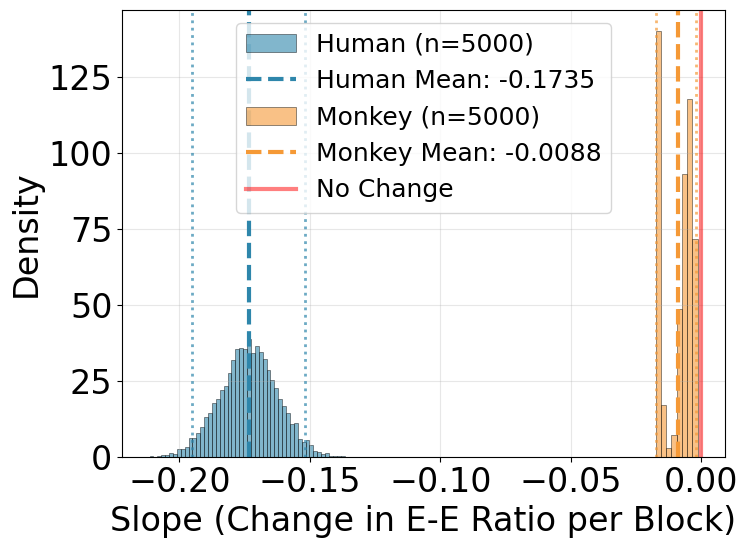

Bootstrap Distribution Analysis Summary:

HUMAN:
  Mean Slope: -0.173541
  95% CI: [-0.195332, -0.152063]
  Significant Proportion: 0.000
  → Significant DECREASE in E-E ratio across blocks

MONKEY:
  Mean Slope: -0.008789
  95% CI: [-0.017266, -0.001990]
  Significant Proportion: 0.000
  → Significant DECREASE in E-E ratio across blocks


In [48]:
def plot_bootstrap_slopes_only(block_results):
    """Create only the bootstrap distribution plot with large fonts."""
    
    # Set global font size
    plt.rcParams.update({'font.size': 24})
    
    # Create figure with specified size
    plt.figure(figsize=(8, 6))
    
    # Extract bootstrap data
    bootstrap_data = block_results['bootstrap_block_analysis']
    
    colors = ['#2E86AB', '#f59936']  # Blue for Human, Purple for Monkey
    species_names = ['Human', 'Monkey']
    
    for i, (species, data) in enumerate(bootstrap_data.items()):
        slopes = data['slopes']
        
        # Create histogram
        if species=="Human":
            plt.hist(slopes, bins=50, alpha=0.6, color=colors[i], 
                label=f"{species} (n={len(slopes)})", density=True, 
                edgecolor='black', linewidth=0.5)
        else:
            plt.hist(slopes, bins=8, alpha=0.6, color=colors[i], 
                label=f"{species} (n={len(slopes)})", density=True, 
                edgecolor='black', linewidth=0.5)
        
        # Add vertical lines for statistics
        plt.axvline(data['mean_slope'], color=colors[i], linestyle='--', linewidth=3, 
                   label=f"{species} Mean: {data['mean_slope']:.4f}")
        plt.axvline(data['slope_ci_95'][0], color=colors[i], linestyle=':', alpha=0.7, linewidth=2)
        plt.axvline(data['slope_ci_95'][1], color=colors[i], linestyle=':', alpha=0.7, linewidth=2)
    
    # Add reference line at zero
    plt.axvline(0, color='red', linestyle='-', alpha=0.5, linewidth=3, label="No Change")
    
    # Labels and formatting
    plt.xlabel('Slope (Change in E-E Ratio per Block)', fontsize=24)
    plt.ylabel('Density', fontsize=24)
    # plt.title('Bootstrap Distribution of E-E Slopes\n(24-Trial Blocks)', 
    #           fontsize=28, fontweight='bold', pad=20)
    
    # Increase tick label size
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
    # Legend with larger font
    plt.legend(fontsize=18)
    
    # Grid
    plt.grid(alpha=0.3)
    
    # Save with high resolution
    plt.tight_layout()
    plt.savefig('bootstrap_slopes_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary for this plot
    print("Bootstrap Distribution Analysis Summary:")
    print("=" * 50)
    
    for species in ['Human', 'Monkey']:
        data = bootstrap_data[species]
        print(f"\n{species.upper()}:")
        print(f"  Mean Slope: {data['mean_slope']:.6f}")
        print(f"  95% CI: [{data['slope_ci_95'][0]:.6f}, {data['slope_ci_95'][1]:.6f}]")
        print(f"  Significant Proportion: {data['significant_proportion']:.3f}")
        
        # Interpret results
        ci_excludes_zero = not (data['slope_ci_95'][0] <= 0 <= data['slope_ci_95'][1])
        
        if ci_excludes_zero and data['mean_slope'] < 0:
            print(f"  → Significant DECREASE in E-E ratio across blocks")
        elif ci_excludes_zero and data['mean_slope'] > 0:
            print(f"  → Significant INCREASE in E-E ratio across blocks")
        else:
            print(f"  → No significant change in E-E ratio across blocks")

# Usage:
plot_bootstrap_slopes_only(block_results)